In [8]:
pip install numpy pandas matplotlib tensorflow


In [1]:
# This Python 3 environment comes with many helpful analytics lipip install numpy pandas matplotlib tensorflow

# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('D:\college\Blood_group\dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

D:\college\Blood_group\dataset\A+\augmented_cluster_0_16.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_17.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2256.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2268.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2269.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2295.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2308.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2322.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2323.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2335.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2358.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2362.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2374.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2383.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2394.BMP
D:\college\Blood_group\dataset\A+\augmented_cluster_0_2399.

Found 6400 images belonging to 8 classes.
Found 1600 images belonging to 8 classes.


d:\college\Blood_group\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 606s 3s/step - accuracy: 0.2861 - loss: 3.0176 - val_accuracy: 0.3181 - val_loss: 1.8341 - learning_rate: 0.0010
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 547s 3s/step - accuracy: 0.3507 - loss: 2.1942 - val_accuracy: 0.3413 - val_loss: 1.7790 - learning_rate: 0.0010
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 544s 3s/step - accuracy: 0.3694 - loss: 1.7015 - val_accuracy: 0.3313 - val_loss: 1.9474 - learning_rate: 0.0010
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.3788 - loss: 1.5867 - val_accuracy: 0.3656 - val_loss: 1.6773 - learning_rate: 0.0010
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.3816 - loss: 1.5565 - val_accuracy: 0.3363 - val_loss: 1.8274 - learning_rate: 0.0010
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.3840 - loss: 1.5441 - val_accuracy: 0.3244 - val_loss: 1.7769 - learning_rate: 0.0010
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.4047 - loss: 1.

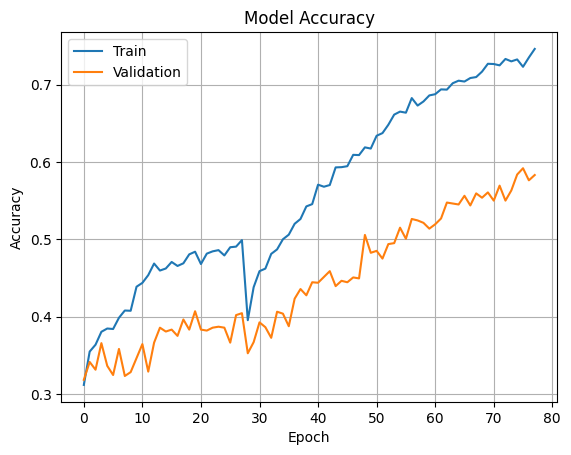

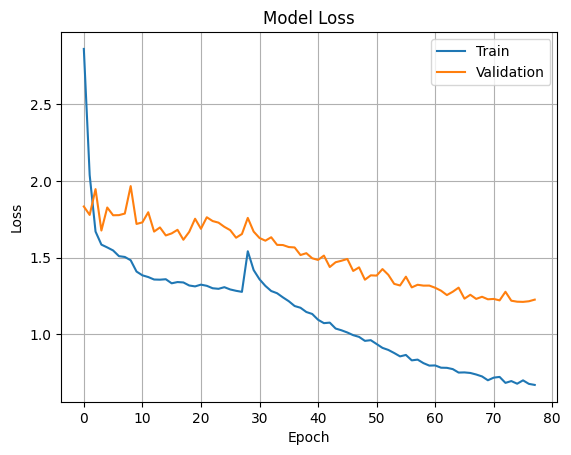

50/50 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step


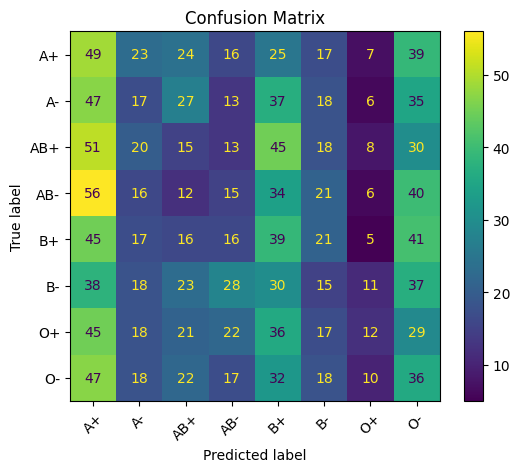


Classification Report:
              precision    recall  f1-score   support

          A+       0.13      0.24      0.17       200
          A-       0.12      0.09      0.10       200
         AB+       0.09      0.07      0.08       200
         AB-       0.11      0.07      0.09       200
          B+       0.14      0.20      0.16       200
          B-       0.10      0.07      0.09       200
          O+       0.18      0.06      0.09       200
          O-       0.13      0.18      0.15       200

    accuracy                           0.12      1600
   macro avg       0.12      0.12      0.12      1600
weighted avg       0.12      0.12      0.12      1600

✅ Model saved successfully as 'blood_group_classifier_final.h5'


In [1]:
# Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Image and batch sizes
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# Dataset path
TRAIN_DIR = r'D:\college\Blood_group\dataset'

# Data augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Data generators
train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Load Xception model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
base_model.trainable = False  # Freeze initially

# Custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

# Final model
model = Model(base_model.input, output)

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# Phase 1: Train with frozen layers
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    steps_per_epoch=train_gen.samples // BATCH_SIZE,
    validation_steps=val_gen.samples // BATCH_SIZE,
    callbacks=[early_stop, reduce_lr]
)

# Fine-tuning Phase 2: Unfreeze last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with low learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tuning
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    steps_per_epoch=train_gen.samples // BATCH_SIZE,
    validation_steps=val_gen.samples // BATCH_SIZE,
    callbacks=[early_stop, reduce_lr]
)

# Evaluate final model
loss, acc = model.evaluate(val_gen)
print(f"\n▶ Final Validation Accuracy: {acc:.2%}, Loss: {loss:.4f}")

# Merge both histories
def combine_history(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

full_history = combine_history(history1, history2)

# Plot accuracy
def plot_accuracy(history):
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid()
    plt.show()

plot_accuracy(full_history)

# Plot loss
def plot_loss(history):
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.grid()
    plt.show()

plot_loss(full_history)

# Predict on validation data
Y_pred = model.predict(val_gen)
y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Save the final model
model.save("blood_group_classifier_final.h5")
print("✅ Model saved successfully as 'blood_group_classifier_final.h5'")


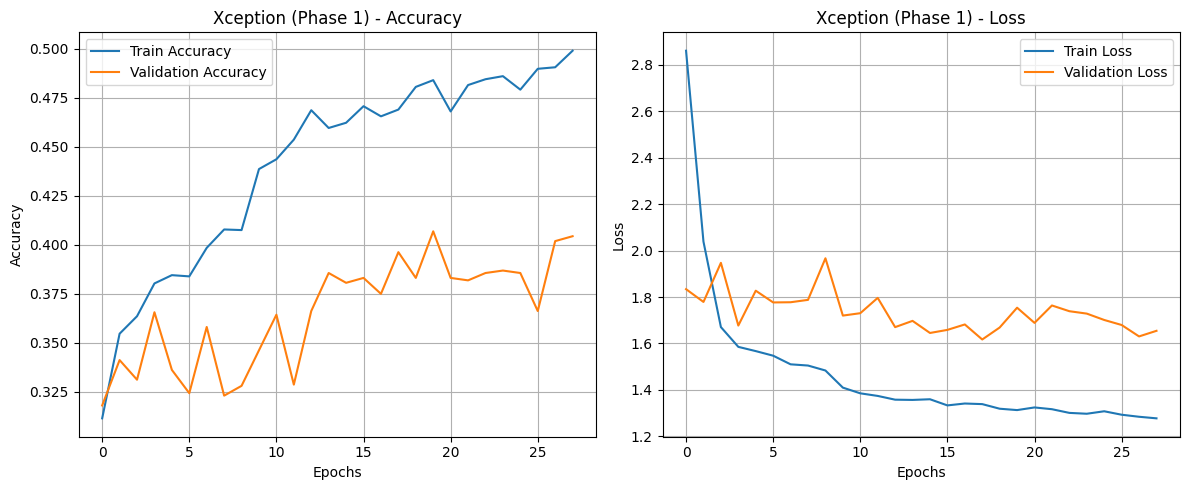

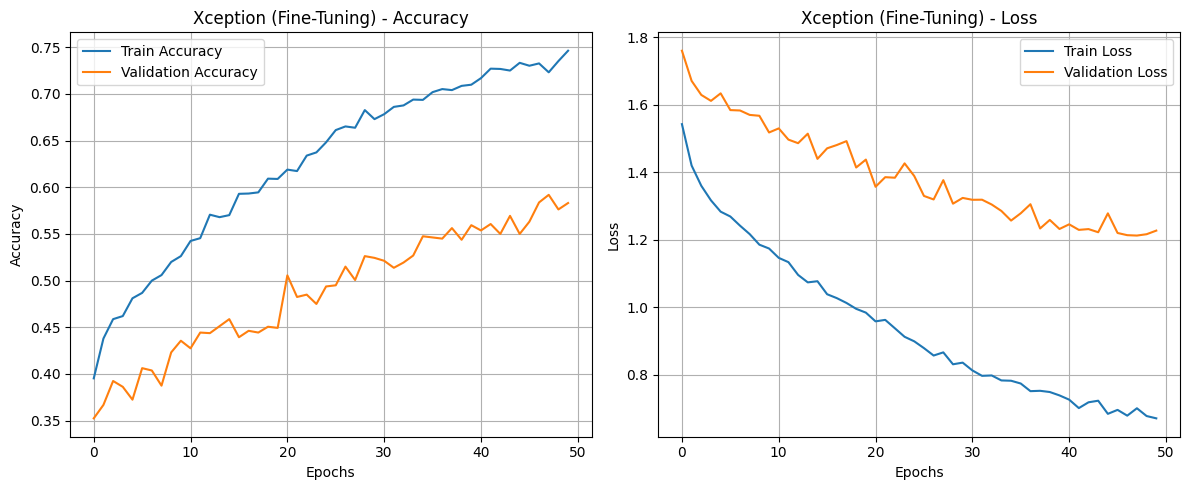

In [2]:
import matplotlib.pyplot as plt

# Function to plot accuracy and loss graphs
def plot_training_history(history, model_name='Model'):
    # Plot Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Usage: plot history of Xception model
plot_training_history(history1, model_name='Xception (Phase 1)')

# If you also want to plot fine-tuning phase history separately:
plot_training_history(history2, model_name='Xception (Fine-Tuning)')


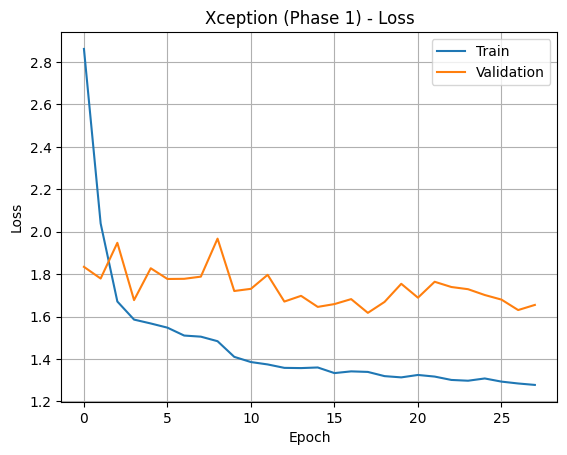

In [3]:
import matplotlib.pyplot as plt

# Function to plot the loss graph for the Xception model
def plot_loss(history, model_name='Model'):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} - Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.grid(True)
    plt.show()

# For first model (Xception), use history1 (frozen base layers)
plot_loss(history1, model_name='Xception (Phase 1)')

# If you want to plot for the fine-tuning phase, use history2:
# plot_loss(history2, model_name='Xception (Fine-Tuning)')


In [2]:
# 📚 Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 📂 Reload saved model
model = load_model("blood_group_classifier_final.h5")
print("✅ Loaded the trained model.")

# ⚙️ Image and batch sizes
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# 📁 Dataset path (same as training)
TEST_DIR = r'D:\college\Blood_group\dataset'

# 🌀 Data generator (only rescaling, NO augmentation for testing)
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # important to keep order
)

# 🔎 Predict on the test data
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)

# 🎯 True labels
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# 📊 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# 📝 Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 🔥 Evaluate model on test set
loss, acc = model.evaluate(test_gen)
print(f"\n▶ Test Set Accuracy: {acc:.2%}, Loss: {loss:.4f}")


KeyboardInterrupt: 

50/50 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step


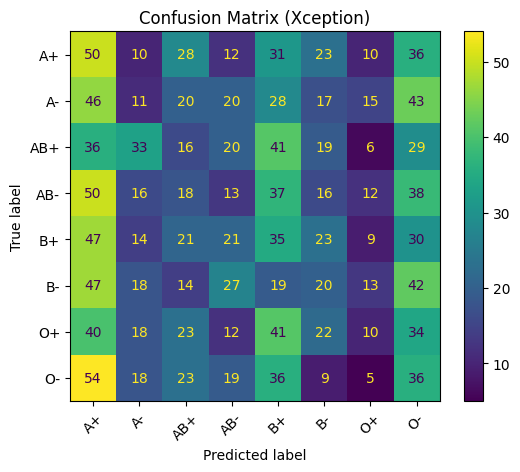

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict on validation data
Y_pred = model.predict(val_gen)  # Make sure to use the first model (Xception)
y_pred = np.argmax(Y_pred, axis=1)

# Get true labels
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)  # Rotate the x-axis labels for readability
plt.title("Confusion Matrix (Xception)")
plt.show()
